# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Simulación de N cuerpos y virialización

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb

np.random.seed(3)

## 1. Creación del sistema de 20 cuerpos

Se genera un conjunto de **N = 20 cuerpos** con masas y posiciones aleatorias en unidades canónicas ($G = 1$, $M_{\rm total} = 1$, escala de posiciones $R = 1$).

Las velocidades iniciales se escalan para que el sistema sea **sub-virial** ($2K/|W| = 0.5$), lo que provoca un colapso parcial seguido de una relajación hacia el equilibrio virial ($2K/|W| \to 1$).

In [9]:
# ── Parámetros ──────────────────────────────────────────────────────────
N = 20
G = 1.0

# Masas aleatorias uniformes en [0.5, 2], normalizadas a M_total = 1
masas = np.random.uniform(0.5, 2.0, N)
masas /= masas.sum()

# Posiciones uniformes en una esfera de radio R = 1
r_mag   = np.random.uniform(0, 1, N) ** (1/3)          # radio (vol. uniforme)
theta   = np.arccos(1 - 2 * np.random.uniform(0, 1, N)) # ángulo polar
phi     = 2 * np.pi * np.random.uniform(0, 1, N)        # ángulo azimutal

pos = np.column_stack([
    r_mag * np.sin(theta) * np.cos(phi),
    r_mag * np.sin(theta) * np.sin(phi),
    r_mag * np.cos(theta)
])

# ── Energía potencial gravitacional ─────────────────────────────────────
W = 0.0
for i in range(N):
    for j in range(i + 1, N):
        rij = np.linalg.norm(pos[i] - pos[j])
        W  -= G * masas[i] * masas[j] / rij

# ── Velocidades iniciales escaladas al 50 % virial ──────────────────────
vel = np.random.normal(0, 1, (N, 3))
vel -= np.average(vel, axis=0, weights=masas)  # eliminar movimiento del CM

K_actual = 0.5 * np.sum(masas[:, None] * vel**2)
K_target  = -W / 4                              # 2K/|W| = 0.5  →  K = |W|/4
vel *= np.sqrt(K_target / K_actual)

K_ini = 0.5 * np.sum(masas[:, None] * vel**2)
print(f"Masas:               {np.round(masas, 4)}")
print(f"Energía potencial  W = {W:.4f}")
print(f"Energía cinética   K = {K_ini:.4f}")
print(f"Razón virial 2K/|W| = {2*K_ini/abs(W):.4f}  (→ 1 tras la virialización)")

Masas:               [0.0579 0.0682 0.0409 0.0552 0.0803 0.0805 0.03   0.0354 0.0252 0.0507
 0.0238 0.0517 0.0643 0.04   0.0661 0.0605 0.0234 0.0584 0.0388 0.049 ]
Energía potencial  W = -0.5655
Energía cinética   K = 0.1414
Razón virial 2K/|W| = 0.5000  (→ 1 tras la virialización)


## 2. Integración con Rebound (IAS15)

Se usa el integrador **IAS15** (Rein & Spiegel 2015), que es de paso adaptativo y de altísima precisión — ideal para manejar encuentros cercanos en sistemas de N cuerpos.

In [10]:
# ── Construir la simulación ──────────────────────────────────────────────
sim = rb.Simulation()
sim.G = G

for i in range(N):
    sim.add(m=masas[i],
            x=pos[i, 0], y=pos[i, 1], z=pos[i, 2],
            vx=vel[i, 0], vy=vel[i, 1], vz=vel[i, 2])

sim.move_to_com()          # referencial del centro de masa

# ── Integrar por T = 5 unidades de tiempo canónicas ─────────────────────
T_total = 5.0
N_snaps = 500
ts      = np.linspace(0, T_total, N_snaps)

traj = np.zeros((N, N_snaps, 3))

for k, t in enumerate(ts):
    sim.integrate(t)
    for j in range(N):
        traj[j, k] = sim.particles[j].xyz

print(f"Integración completada: {N} cuerpos durante {T_total} u.t.c. ({N_snaps} snapshots)")

Integración completada: 20 cuerpos durante 5.0 u.t.c. (500 snapshots)


## 3. Trayectorias en el plano XY

Cada color corresponde a un cuerpo.  
- **Círculo** ($\\circ$): posición inicial  
- **Estrella** ($\\star$): posición final  
- El tamaño del marcador es proporcional a la masa.

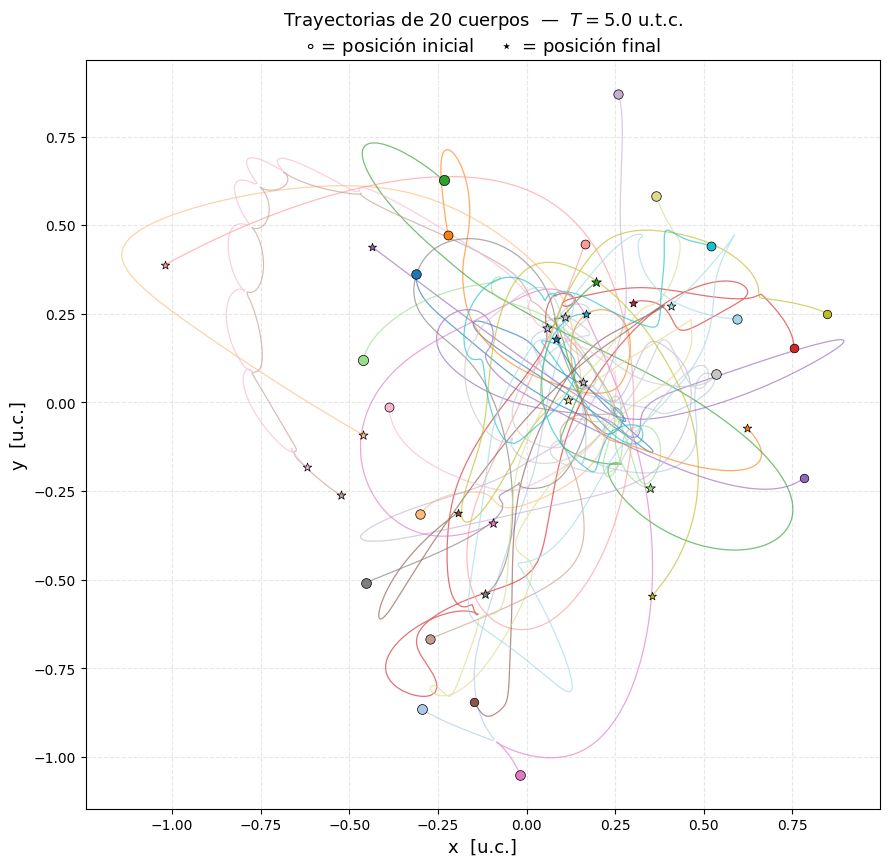

In [11]:
fig, ax = plt.subplots(figsize=(9, 9))
colors = plt.cm.tab20(np.arange(N) / N)

for j in range(N):
    s = masas[j] * 300 + 30          # tamaño ∝ masa
    ax.plot(traj[j, :, 0], traj[j, :, 1],
            color=colors[j], alpha=0.65, lw=0.9)
    # posición inicial
    ax.scatter(traj[j, 0, 0], traj[j, 0, 1],
               color=colors[j], s=s, marker='o', zorder=5,
               edgecolors='k', linewidths=0.5)
    # posición final
    ax.scatter(traj[j, -1, 0], traj[j, -1, 1],
               color=colors[j], s=s, marker='*', zorder=5,
               edgecolors='k', linewidths=0.5)

ax.set_xlabel('x  [u.c.]', fontsize=13)
ax.set_ylabel('y  [u.c.]', fontsize=13)
ax.set_title(
    f'Trayectorias de {N} cuerpos  —  $T = {T_total}$ u.t.c.\n'
    r'$\circ$ = posición inicial $\quad \star$ = posición final',
    fontsize=13
)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [12]:
import plotly.graph_objects as go

colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

fig3d = go.Figure()

for j in range(N):
    s_marker = int(masas[j] * 120 + 4)
    # Trayectoria
    fig3d.add_trace(go.Scatter3d(
        x=traj[j, :, 0], y=traj[j, :, 1], z=traj[j, :, 2],
        mode='lines',
        line=dict(color=colors_hex[j], width=2),
        opacity=0.7,
        name=f'Cuerpo {j+1}',
        showlegend=False
    ))
    # Posición inicial
    fig3d.add_trace(go.Scatter3d(
        x=[traj[j, 0, 0]], y=[traj[j, 0, 1]], z=[traj[j, 0, 2]],
        mode='markers',
        marker=dict(color=colors_hex[j], size=s_marker, symbol='circle',
                    line=dict(color='black', width=1)),
        name=f'Inicio {j+1}',
        showlegend=False
    ))
    # Posición final
    fig3d.add_trace(go.Scatter3d(
        x=[traj[j, -1, 0]], y=[traj[j, -1, 1]], z=[traj[j, -1, 2]],
        mode='markers',
        marker=dict(color=colors_hex[j], size=s_marker, symbol='diamond',
                    line=dict(color='black', width=1)),
        name=f'Fin {j+1}',
        showlegend=False
    ))

fig3d.update_layout(
    title=dict(
        text=f'Trayectorias 3D — {N} cuerpos — T = {T_total} u.t.c.<br>'
             '<sup>● posición inicial &nbsp;&nbsp; ◆ posición final</sup>',
        x=0.5
    ),
    scene=dict(
        xaxis_title='x [u.c.]',
        yaxis_title='y [u.c.]',
        zaxis_title='z [u.c.]',
        aspectmode='data'
    ),
    width=850, height=750,
    margin=dict(l=0, r=0, b=0, t=60)
)

fig3d.show()

## 5. Animación 3D del sistema

In [13]:
import plotly.graph_objects as go

colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

# Submuestreo para que la animación sea fluida pero no pesada
n_frames = 120
idx = np.linspace(0, N_snaps - 1, n_frames, dtype=int)

s_markers = [max(4, int(masas[j] * 120 + 4)) for j in range(N)]

# ── Traza base: trayectorias completas (fondo estático) ─────────────────
base_traces = []
for j in range(N):
    base_traces.append(go.Scatter3d(
        x=traj[j, :, 0], y=traj[j, :, 1], z=traj[j, :, 2],
        mode='lines',
        line=dict(color=colors_hex[j], width=1),
        opacity=0.25,
        showlegend=False,
        hoverinfo='skip'
    ))

# Posiciones iniciales de los cuerpos (frame 0)
for j in range(N):
    base_traces.append(go.Scatter3d(
        x=[traj[j, idx[0], 0]],
        y=[traj[j, idx[0], 1]],
        z=[traj[j, idx[0], 2]],
        mode='markers',
        marker=dict(color=colors_hex[j], size=s_markers[j],
                    line=dict(color='black', width=0.5)),
        name=f'Cuerpo {j+1}',
        showlegend=False
    ))

# ── Frames ───────────────────────────────────────────────────────────────
frames = []
for fi, ki in enumerate(idx):
    frame_data = []
    # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
    for j in range(N):
        frame_data.append(go.Scatter3d(
            x=[traj[j, ki, 0]],
            y=[traj[j, ki, 1]],
            z=[traj[j, ki, 2]],
        ))
    frames.append(go.Frame(
        data=frame_data,
        traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
        name=str(fi)
    ))

# ── Figura ───────────────────────────────────────────────────────────────
fig_anim = go.Figure(data=base_traces, frames=frames)

fig_anim.update_layout(
    title=dict(
        text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
        x=0.5
    ),
    scene=dict(
        xaxis_title='x [u.c.]',
        yaxis_title='y [u.c.]',
        zaxis_title='z [u.c.]',
        aspectmode='data'
    ),
    width=860, height=760,
    margin=dict(l=0, r=0, b=0, t=50),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=0.02, x=0.5, xanchor='center',
        buttons=[
            dict(label='▶ Play',
                 method='animate',
                 args=[None, dict(frame=dict(duration=40, redraw=True),
                                  fromcurrent=True, mode='immediate')]),
            dict(label='⏸ Pausa',
                 method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                    mode='immediate')])
        ]
    )],
    sliders=[dict(
        currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
        pad=dict(t=40),
        steps=[dict(method='animate',
                    args=[[str(fi)], dict(mode='immediate',
                                          frame=dict(duration=0, redraw=True))],
                    label=str(fi))
               for fi in range(n_frames)]
    )]
)

fig_anim.show()